# Generate a forecast with AIFS Single v2

This notebook demonstrates how to generate a forecast with AIFS Single v2 using:
- ECMWF [open data](https://www.ecmwf.int/en/forecasts/datasets/open-data) 
- [anemoi-inference](https://anemoi-inference.readthedocs.io/en/latest/)
- the `aifs_single_v2.0.ckpt` checkpoint - note this checkpoint only contains the model weights. It cannot be used for fine-tuning as it does not contain any information about the optimizer states, lr-scheduler states, etc.

# Prerequisites

This notebook requires:
- Python 3.11 or 3.12
- Ampere GPUs or newer (this notebook has been tested in Colab using the **L4** and **A100** runtimes, and on ECMWF's ATOS HPCF **AC cluster**)
- Several GB of writable disk space

Known limitations:
- Even with compatible GPUs, this notebook may not work out-of-the-box on all systems. A compataible CUDA/PyTorch/FlashAttention environment is required. See https://github.com/Dao-AILab/flash-attention?tab=readme-ov-file#installation-and-features for more details.

# 1. Install dependencies

Uncomment the lines below to install the required packages, or use the provided pyproject or lock files to install the dependencies in your environment.

### To run this notebook in Colab (L4 or A100 runtimes)

In [ ]:
# !pip install -q anemoi-inference[huggingface]==0.8.3 anemoi-models==0.9.3 anemoi-utils==0.4.35.post3
# !pip install -q torch==2.7.0 torch-geometric==2.6.1
# !pip install -q earthkit-regrid==0.5.1 ecmwf-opendata==0.3.29 'earthkit-data<1.0.0'
# !pip install -q flash-attn==2.7.4.post1

### To run this notebook through JupyterHub on ECMWF's ATOS HPCF

If you have access to GPUs on ECMWF's ATOS HPCF, you can run this notebook through [JupyterHub](https://jupyterhub.ecmwf.int/). 

Select the **ECMWF ATOS HPCF - GPU partition**

**Note:** The quick-start method below installs packages in your personal Python package directory for the active Jupyter kernel. This is convenient for running the notebook, but it may affect other notebooks that use the same Python environment. We recommend creating a dedicated Python environment and registering it as a Jupyter kernel.

In [ ]:
# %pip install anemoi-inference[huggingface]==0.8.3 anemoi-models==0.9.3 anemoi-utils==0.4.35.post3
# %pip install -q torch==2.7.0 torch-geometric==2.6.1
# %pip install -q earthkit-regrid==0.5.1 ecmwf-opendata==0.3.29 'earthkit-data<1.0.0'
# %pip install -q --force-reinstall --no-deps "flash-attn @ https://github.com/cathalobrien/get-flash-attn/releases/download/v0.1-alpha/flash_attn-2.8.3+cu12torch2.7cxx11abiFALSE-cp312-cp312-linux_x86_64.whl"

# 2. Check runtime environment

In [ ]:
import platform
import torch

print("Platform:", platform.platform())
print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if not torch.cuda.is_available():
    raise RuntimeError("CUDA GPU not available. This notebook requires a GPU.")

# See https://github.com/huggingface/transformers/issues/28188
gpu_name = torch.cuda.get_device_name(0)
major, minor = torch.cuda.get_device_capability(0)

print("GPU:", gpu_name)
print(f"Compute capability: {major}.{minor}")

if major < 8:
    raise RuntimeError(
        "FlashAttention requires Ampere GPUs or newer"
    )

In [ ]:
import flash_attn

print("FlashAttention:", flash_attn.__version__)

# 3. Import packages

In [ ]:
import datetime
from collections import defaultdict

import numpy as np

import earthkit.data as ekd
import earthkit.regrid as ekr

from anemoi.inference.runners.simple import SimpleRunner
from anemoi.inference.outputs.printer import print_state

from ecmwf.opendata import Client as OpendataClient

Store downloaded ECMWF data in local cache:


In [ ]:
ekd.config.set({'cache-policy': 'user'})

# 4. Prepare retrieval of initial conditions

Initial conditions are the initial state used by the model.

### List parameters to retrieve from ECMWF open data

In [ ]:
PARAM_SFC = ["10u", "10v", "2d", "2t", "msl", "skt", "sp", "tcw", "lsm", "z", "slor", "sdor", "sd"]
PARAM_SOIL =["vsw","sot"]
PARAM_WAVE =["wmb", "h1012", "h1214", "h1417", "h1721", "h2125", "h2530", "mwd", "cdww", "mwp", "swh"]
PARAM_PL  = ["gh", "t", "u", "v", "q"]
LEVELS = [1000, 925, 850, 700, 600, 500, 400, 300, 250, 200, 150, 100, 50, 10]
SOIL_LEVELS = [1,2]

### Choose open data source and set the latest available date

In [ ]:
SOURCE = "ecmwf" # Other options are: "azure", "aws", or "google"

DATE = OpendataClient(SOURCE).latest()
print("Initial date is", DATE)

Some requested dates are before 2026-05-12. Data before this date uses a different stream structure (06/18 UTC runs are under stream=scda/scwv) compared to data on or after 2026-05-12 (where those runs are under stream=oper/wave). This is handled automatically, but be aware that the underlying file structure differs across this boundary.


Initial date is 2026-04-23 12:00:00


### Create function to download and interpolate data from the ECMWF Open Data API

In [ ]:
def get_open_data(param, levelist=[], **kwargs):
    fields = defaultdict(list)
    # Get the data for the current date and the previous date as the model is initialised with t-6h data
    for date in [DATE - datetime.timedelta(hours=6), DATE]:
        data = ekd.from_source("ecmwf-open-data", date=date, param=param, levelist=levelist, source = SOURCE, **kwargs)
        
        for f in data: # type: ignore
            # Open data is between -180 and 180, we need to shift it to 0-360
            assert f.to_numpy().shape == (721,1440)
            values = np.roll(f.to_numpy(), -f.shape[1] // 2, axis=1)
            # Interpolate the data to from 0.25 to N320
            values = ekr.interpolate(values, {"grid": (0.25, 0.25)}, {"grid": "N320"})
            # Add the values to the list
            name = f"{f.metadata('param')}_{f.metadata('levelist')}" if levelist else f.metadata("param")
            fields[name].append(values)

    # Create a single matrix for each parameter
    for param, values in fields.items():
        fields[param] = np.stack(values)

    return fields

### Store model input fields

In [ ]:
fields = {}

# 5. Download initial conditions from ECMWF open data

Downloads can take several minutes and may be interrupted during peak times.

### Download surface fields

In [ ]:
fields.update(get_open_data(param=PARAM_SFC, levtype="sfc"))
assert all(p in fields for p in PARAM_SFC), "Missing parameters: %s" % (set(PARAM_SFC) - set(fields.keys()))

By downloading data from the ECMWF open data dataset, you agree to the terms: Attribution 4.0 International (CC BY 4.0). Please attribute ECMWF when downloading this data.


### Download wave fields

In [ ]:
fields.update(get_open_data(param=PARAM_WAVE, stream="wave"))
assert all(p in fields for p in PARAM_WAVE), "Missing parameters: %s" % (set(PARAM_WAVE) - set(fields.keys()))

### Download soil fields

In [ ]:
soil=get_open_data(param=PARAM_SOIL,levelist=SOIL_LEVELS)

soil_names = [f"{p}_{lev}" for p in PARAM_SOIL for lev in SOIL_LEVELS]
assert all(p in soil for p in soil_names), "Missing parameters: %s" % (set(soil_names) - set(soil.keys()))

### Download pressure level fields

In [ ]:
fields.update(get_open_data(param=PARAM_PL, levelist=LEVELS))

PRESSURE_NAMES = [f"{p}_{lev}" for p in PARAM_PL for lev in LEVELS]
assert all(p in fields for p in PRESSURE_NAMES), "Missing parameters: %s" % (set(PRESSURE_NAMES) - set(fields.keys()))

# 6. Apply data transformations

AIFS Single v2 expects the data to match the data it was trained on.

Transform the mean wave direction into sine and cosine components:

In [ ]:
mwd = fields.pop("mwd")
mwd_rad = np.deg2rad(mwd)

fields["cos_mwd"] = np.cos(mwd_rad)
fields["sin_mwd"] = np.sin(mwd_rad)

Rename soil fields:

In [ ]:
mapping = {'sot_1': 'stl1', 'sot_2': 'stl2',
           'vsw_1': 'swvl1','vsw_2': 'swvl2'}
for k,v in soil.items():
    fields[mapping[k]]=v

Remove unused specific humidity fields:

In [ ]:
fields.pop("q_10", None)  # Remove the 10hPa level for specific humidity, as it is not used in the model
fields.pop("q_50", None);  # Remove the 50hPa level for specific humidity, as it is not used as a prognostic in the model

Apply land-sea mask:

In [ ]:
mask = np.equal(ekd.from_source("file", 'lsm.grib')[0].to_numpy(flatten=True), 0)

fields["sd"][:, mask] = np.nan
fields["swvl1"][:, mask] = np.nan
fields["swvl2"][:,mask] = np.nan

Convert geopotential height into geopotential:

In [ ]:
# Transform GH to Z
for level in LEVELS:
    gh = fields.pop(f"gh_{level}")
    fields[f"z_{level}"] = gh * 9.80665

# 7. Create initial forecast state

In [ ]:
input_state = dict(date=DATE, fields=fields)

# 8. Load AIFS Single v2 model

### Download the model checkpoint from Hugging Face

In [ ]:
checkpoint = {"huggingface":"ecmwf/aifs-single-2.0"}

To reduce the memory usage of the model one can set certain environment variables, like the number of chunks of the model's mapper.
Please refer to:
- https://anemoi.readthedocs.io/projects/models/en/latest/modules/layers.html#anemoi-inference-num-chunks
- https://pytorch.org/docs/stable/notes/cuda.html#optimizing-memory-usage-with-pytorch-cuda-alloc-conf

for more information. To do so, use the code below:
```
import os
os.environ['PYTORCH_CUDA_ALLOC_CONF']='expandable_segments:True' 
os.environ['ANEMOI_INFERENCE_NUM_CHUNKS']='16'
```

### Create a runner

In [ ]:
runner = SimpleRunner(checkpoint)

**Note - changing the device from GPU to CPU**

- Running the transformer model used on the CPU is tricky, it depends on the FlashAttention library which only supports Nvidia and AMD GPUs, and is optimised for performance and memory usage
- In newer versions of anemoi-models, v0.4.2 and above, there is an option to switch off flash attention and uses Pytorchs Scaled Dot Product Attention (SDPA). The code snippet below shows how to overwrite a model from a checkpoint to use SDPA. Unfortunately it's not optimised for memory usage in the same way, leading to much greater memory usage. Please refer to https://github.com/ecmwf/anemoi-inference/issues/119 for more details 

# 9. Run the model to generate a forecast

The example below is a 12-hour forecast for demonstration purposes. Change the LEAD_TIME to modify the forecast length.

In [ ]:
LEAD_TIME = 12

states = []

for state in runner.run(input_state=input_state, lead_time=LEAD_TIME):
    states.append(state)
    print_state(state)

Fetching 10 files: 100%|██████████| 10/10 [00:00<00:00, 4977.81it/s]
Coupled forcings are not supported by this runner: ['lsm', 'sdor', 'slor', 'wmb', 'z']
NaNs found in the following variables: ['cdww', 'cos_mwd', 'h1012', 'h1214', 'h1417', 'h1721', 'h2125', 'h2530', 'mwp', 'sd', 'sin_mwd', 'swh', 'swvl1', 'swvl2', 'wmb']



😀 date=2026-04-23T12:00:00 latitudes=(542080,) longitudes=(542080,) fields=120

    100u    shape=(542080,) min=-26.667        max=31.8393       
    q_700   shape=(542080,) min=0              max=0.0108053     
    t_925   shape=(542080,) min=233.925        max=310.293       
    v_850   shape=(542080,) min=-37.5684       max=29.1458       
    z_925   shape=(542080,) min=1529.04        max=9216.23       


😀 date=2026-04-23T18:00:00 latitudes=(542080,) longitudes=(542080,) fields=120

    100u    shape=(542080,) min=-27.0889       max=32.8942       
    q_700   shape=(542080,) min=0              max=0.0105684     
    t_925   shape=(542080,) min=234.285        max=310.524       
    v_850   shape=(542080,) min=-39.2659       max=30.3254       
    z_925   shape=(542080,) min=600.896        max=9244.63       



### Note
Users should not expect this notebook to reproduce ECMWF operational AIFS forecasts exactly. This is due to two factors:

#### 1. GPU non-determinism
GPU operations are not always bitwise deterministic, meaning repeated runs can produce slightly different numerical results.

To enforce determinism at GPU level, the following settings can be configured:

```
#First, in a terminal
export CUBLAS_WORKSPACE_CONFIG=:4096:8

#And then before running inference:
import torch
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True
torch.use_deterministic_algorithms(True)

```
Please note that using the above approach to enable deterministic behaviour will **significantly** increase runtime. 

#### 2. Differences in input data reprojection 
The initial conditions used in this notebook are downloaded from ECMWF open data. The data is provided on a 0.25° latitude/longitude grid and reprojected to the N320 grid for use by the AIFS.

In ECMWF's operational forecasting system, the initial conditions come directly from operational IFS analyses on the native o1280 grid and are reprojected directly to N320.

These differing reprojection pathways can introduce small differences in the model input fields, which may lead to minor differences in the resulting forecasts.

# 10. Optional: Inspect the forecast

#### Plot a field (e.g. 100u)

In [ ]:
# To be able to run the plotting section below you need to install additional dependencies, or use the provided pyproject or lock files to install the dependencies in your environment.

# !pip install -q matplotlib cartopy

In [ ]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.tri as tri

In [ ]:
def fix(lons):
    # Shift the longitudes from 0-360 to -180-180
    return np.where(lons > 180, lons - 360, lons)

latitudes = state["latitudes"]
longitudes = state["longitudes"]
values = state["fields"]["100u"]

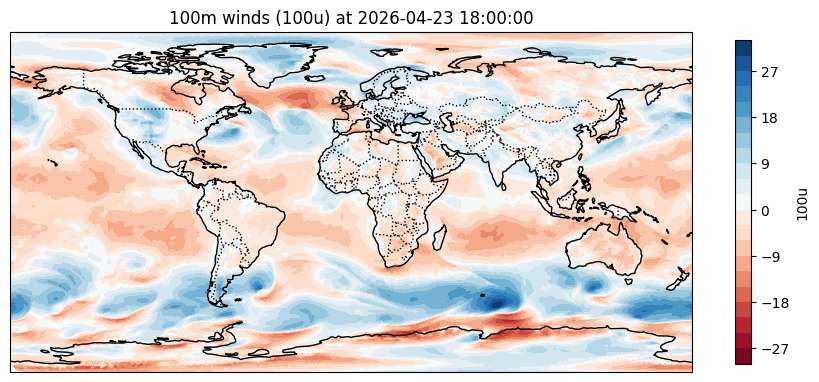

In [ ]:
fig, ax = plt.subplots(figsize=(11, 6), subplot_kw={"projection": ccrs.PlateCarree()})
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=":")

triangulation = tri.Triangulation(fix(longitudes), latitudes)

contour=ax.tricontourf(triangulation, values, levels=20, transform=ccrs.PlateCarree(), cmap="RdBu")
cbar = fig.colorbar(contour, ax=ax, orientation="vertical", shrink=0.7, label="100u")

plt.title("100m winds (100u) at {}".format(state["date"]))
plt.show()